In [1]:
# !pip install torch torchvision albumentations pandas scikit-learn pillow matplotlib
import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

/Users/nadiaroschina/Library/Mobile Documents/com~apple~CloudDocs/masters_icloud/PROJECT/teeth_classes_classification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.11.0
CUDA available: False


In [2]:
from utils_2_dataloader import (
    ToothDataset,
    load_and_prepare_data,
    get_transforms,
    create_dataloaders,
    TOOTH_ID_TO_CLASS_NAME,
    IDX_TO_CLASS_NAME,
    CLASS_MAPPING_RULES,
    DATA_DIR,
    JSON_PATH,
)

In [3]:
train_loader, val_loader, test_loader = create_dataloaders(batch_size=16, num_workers=2)

print("\n--- Checking Train Batch ---")
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # Ожидается [16, 3, 224, 224]
print(f"Labels batch: {labels}")
print(f"Unique classes in batch: {[IDX_TO_CLASS_NAME[l.item()] for l in torch.unique(labels)]}")

Всего валидных сэмплов: 3584
  incisor: 520 (14.5%)
  canine: 254 (7.1%)
  premolar: 1140 (31.8%)
  molar: 1670 (46.6%)
Разбивка -> Train: 2508, Val: 538, Test: 538

--- Checking Train Batch ---


/Users/nadiaroschina/Library/Mobile Documents/com~apple~CloudDocs/masters_icloud/PROJECT/teeth_classes_classification/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Batch shape: torch.Size([16, 3, 224, 224])
Labels batch: tensor([3, 2, 0, 2, 3, 2, 3, 2, 0, 0, 3, 0, 3, 3, 2, 2])
Unique classes in batch: ['incisor', 'premolar', 'molar']


In [4]:
print("\n--- Class Distribution Check (Train) ---")

all_labels_train = []
for _, lbls in train_loader:
    all_labels_train.extend(lbls.tolist())

counts = Counter(all_labels_train)
total = sum(counts.values())
for idx, count in sorted(counts.items()):
    print(f"  Class '{IDX_TO_CLASS_NAME[idx]}': {count} samples ({count / total * 100:.1f}%)")


--- Class Distribution Check (Train) ---
  Class 'incisor': 364 samples (14.5%)
  Class 'canine': 178 samples (7.1%)
  Class 'premolar': 798 samples (31.8%)
  Class 'molar': 1168 samples (46.6%)


In [5]:
# --- ФУНКЦИИ ДЛЯ ВИЗУАЛИЗАЦИИ ---

def get_vis_transforms(img_size: int = 224) -> A.Compose:
    """
    Аугментации БЕЗ нормализации — только для визуализации.
    Повторяет набор аугментаций из get_transforms(is_training=True),
    но возвращает uint8 numpy array в диапазоне 0-255.
    """
    return A.Compose([
        A.Resize(height=img_size, width=img_size),
        A.HorizontalFlip(p=0.5),
        A.RandomRotate90(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
        A.GaussNoise(std_range=(10 / 255, 25 / 255), p=0.3),
        # Нормализация намеренно отсутствует: нужны реальные цвета для отображения
    ])


def _build_vis_mapping(json_path: Path) -> dict:
    """Читает JSON и возвращает {filename: tooth_id_str}, поддерживая оба формата ключей."""
    with open(json_path, "r", encoding="utf-8") as f:
        raw = json.load(f)
    mapping = {}
    for key, tooth_id in raw.items():
        key_str = str(key).strip()
        fname = key_str if key_str.endswith(".jpg") else f"{int(key_str):05d}.jpg"
        mapping[fname] = str(tooth_id)
    return mapping


def visualize_samples(data_dir: Path, json_path: Path, num_samples: int = 6) -> None:
    """
    Отображает num_samples случайных изображений: оригинал и аугментированная версия.
    """
    tooth_mapping = _build_vis_mapping(json_path)

    image_files = sorted(f.name for f in data_dir.glob("*.jpg"))
    valid_files = [
        f for f in image_files
        if f in tooth_mapping and tooth_mapping[f] in TOOTH_ID_TO_CLASS_NAME
    ]

    if not valid_files:
        print("Нет валидных изображений для визуализации.")
        return

    if len(valid_files) < num_samples:
        print(f"Warning: найдено только {len(valid_files)} валидных изображений.")
        num_samples = len(valid_files)

    selected_files = random.sample(valid_files, num_samples)
    transform = get_vis_transforms()

    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 5 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    print(f"Visualizing {num_samples} random samples...\n")

    for i, fname in enumerate(selected_files):
        tooth_id = tooth_mapping[fname]
        class_name = TOOTH_ID_TO_CLASS_NAME[tooth_id]
        img_path = data_dir / fname

        image_np = np.array(Image.open(img_path).convert("RGB"))
        aug_image_np = transform(image=image_np)["image"]

        axes[i, 0].imshow(image_np)
        axes[i, 0].set_title(
            f"Original\nFile: {fname}\nTooth ID: {tooth_id}\nClass: {class_name}",
            fontsize=11, fontweight="bold",
        )
        axes[i, 0].axis("off")

        axes[i, 1].imshow(aug_image_np)
        axes[i, 1].set_title(
            f"Augmented\n(Random Transform Applied)\nClass: {class_name}",
            fontsize=11, color="darkgreen", fontweight="bold",
        )
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

Visualizing 5 random samples...



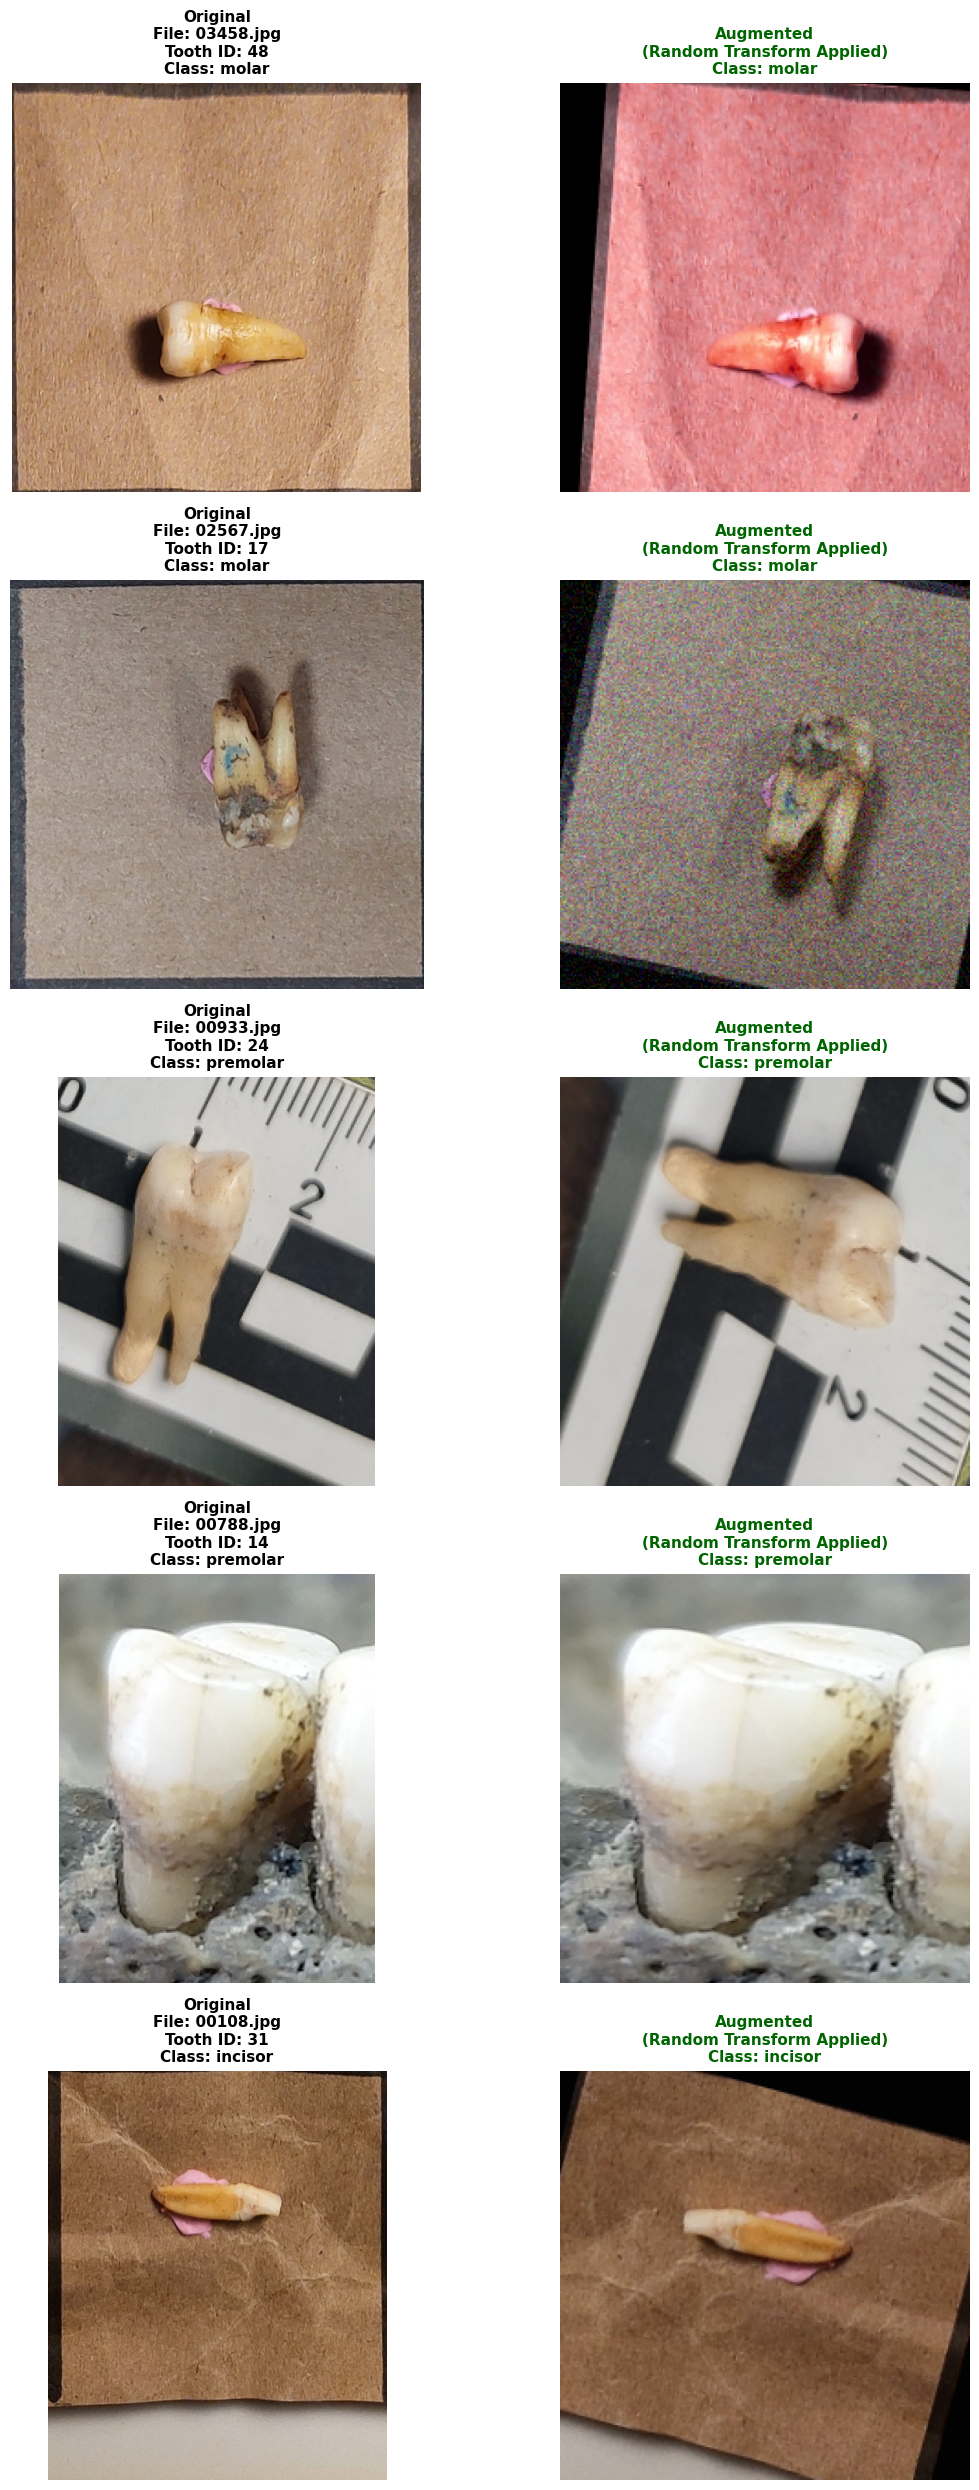

In [7]:
visualize_samples(DATA_DIR, JSON_PATH, num_samples=5)